Notebook used to read the distribution of data in the training dataset.

In [1]:
%cd ..

/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo


In [2]:
from gerumo import *
import numpy as np
import matplotlib.pyplot as plt

/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/raw/MST_NectarCam.npy not found.
File ML1/raw/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/simple/MST_NectarCam.npy not found.
File ML1/simple/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/simple_shift/MST_NectarCam.npy not found.
File ML1/simple_shift/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/time/MST_NectarCam.npy not found.
File ML1/time/MST_NectarCam not found
/home/sven-klein-plarre/Documentos/Universidad/Magister/Tesis/Repositorio-GERUMO/gerumo/gerumo/data/pixels_positions/ML1/time_shift/MST_NectarCam.npy not found.
File ML1/time_shift/MST_NectarCam not found
/home

2026-06-08 19:50:03.901915: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-08 19:50:03.925649: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-08 19:50:03.925680: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-08 19:50:03.926326: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-08 19:50:03.930785: I tensorflow/core/platform/cpu_feature_guar

In [3]:
events_direction = "./dataset/gamma-diffuse only/events.csv"
telescopes_direction = "./dataset/gamma-diffuse only/telescopes.csv"

In [4]:
dataset = load_dataset(events_direction, telescopes_direction)
dataset = aggregate_dataset(dataset,az=True,log10_mc_energy=True)
describe_dataset(dataset)

files 35
events 1182736
observations 3262013
obsevation by telescopes
type
MST    2369825
LST     892188
Name: count, dtype: int64


In [5]:
alt_min = dataset["alt"].min()
alt_max = dataset["alt"].max()
az_min = dataset["az"].min()
az_max = dataset["az"].max()
log10_energy_min = dataset["log10_mc_energy"].min()
log10_energy_max = dataset["log10_mc_energy"].max()
alt_range = np.linspace(alt_min,alt_max,101)
az_range = np.linspace(az_min,az_max,101)
log10_energy_range = np.linspace(log10_energy_min,log10_energy_max,101)
alt_distribution = np.zeros(100)
az_distribution = np.zeros(100)
log10_energy_distribution = np.zeros(100)

In [6]:
for _,row in dataset.iterrows():
    for n in range(100):
        if row["alt"] <= alt_range[n+1]:
            alt_distribution[n] += 1
            break
    for n in range(100):
        if row["az"] <= az_range[n+1]:
            az_distribution[n] += 1
            break
    for n in range(100):
        if row["log10_mc_energy"] <= log10_energy_range[n+1]:
            log10_energy_distribution[n] +=1
            break

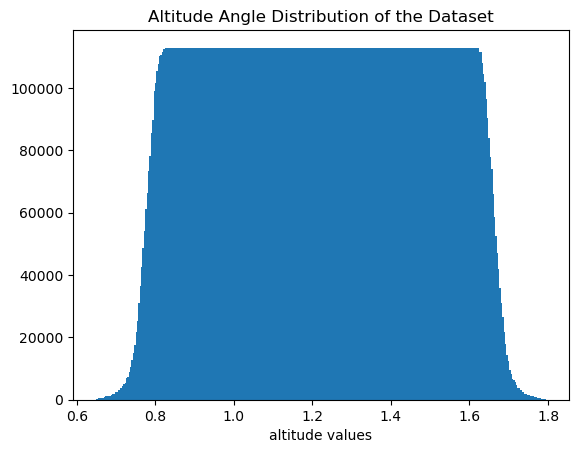

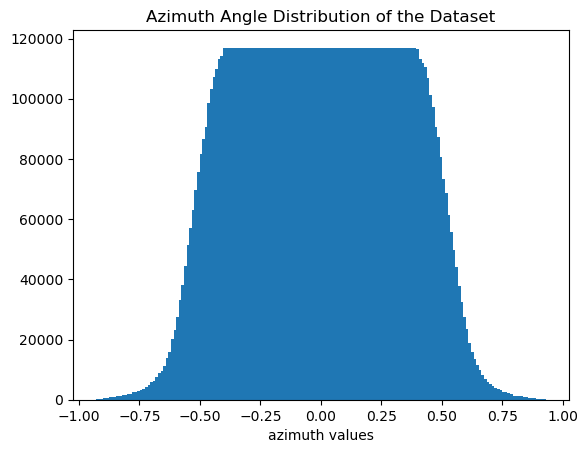

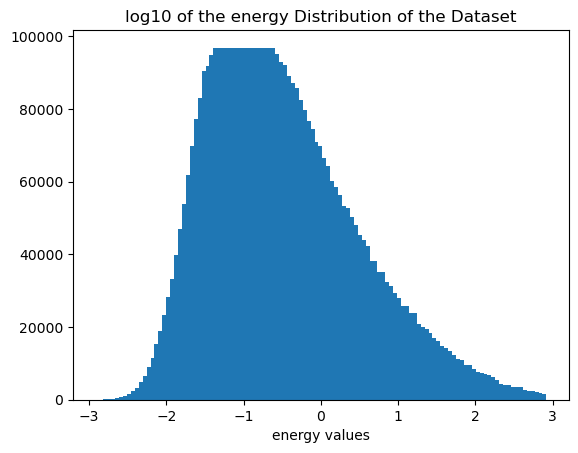

In [7]:
plt.bar(np.linspace(alt_min, alt_max, 100), alt_distribution)
plt.xlabel("altitude values")
plt.title("Altitude Angle Distribution of the Dataset")
plt.show()
plt.bar(np.linspace(az_min, az_max, 100), az_distribution)
plt.xlabel("azimuth values")
plt.title("Azimuth Angle Distribution of the Dataset")
plt.show()
plt.bar(np.linspace(log10_energy_min, log10_energy_max, 100), log10_energy_distribution)
plt.xlabel("energy values")
plt.title("log10 of the energy Distribution of the Dataset")
plt.show()

LST Telescopes

In [10]:
LST_dataset = dataset[dataset.type.isin(["LST"])]
alt_distribution_LST = np.zeros(100)
az_distribution_LST = np.zeros(100)
log10_energy_distribution_LST = np.zeros(100)

In [12]:
for _,row in LST_dataset.iterrows():
    for n in range(100):
        if row["alt"] <= alt_range[n+1]:
            alt_distribution_LST[n] += 1
            break
    for n in range(100):
        if row["az"] <= az_range[n+1]:
            az_distribution_LST[n] += 1
            break
    for n in range(100):
        if row["log10_mc_energy"] <= log10_energy_range[n+1]:
            log10_energy_distribution_LST[n] +=1
            break

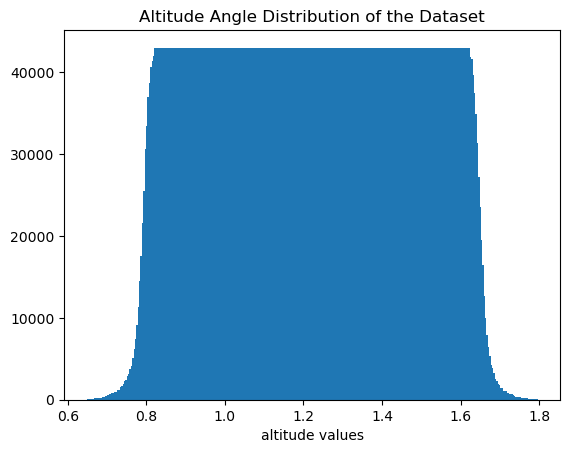

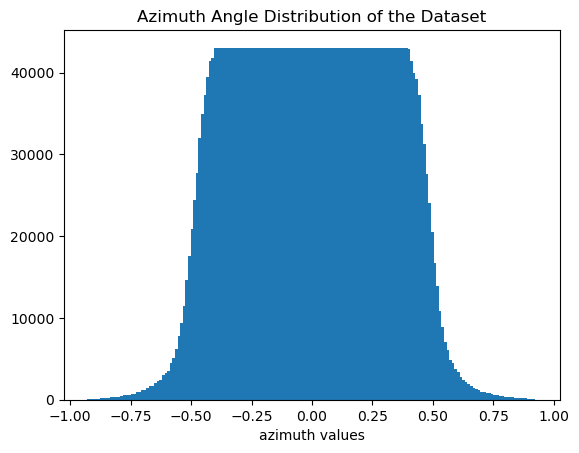

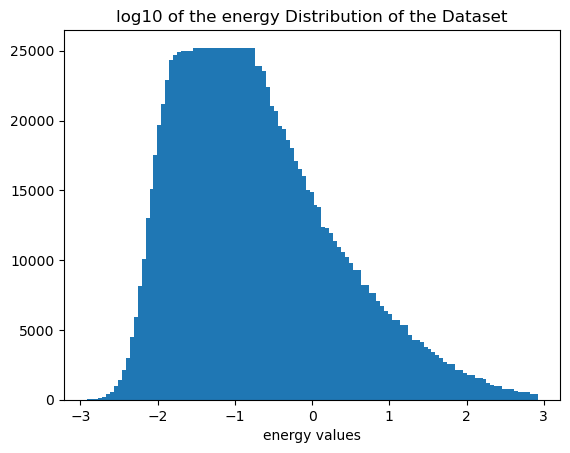

In [ ]:
plt.bar(np.linspace(alt_min, alt_max, 100), alt_distribution_LST)
plt.xlabel("altitude values")
plt.title("Altitude Angle Distribution of the Dataset for LST_LSTCam")
plt.show()
plt.bar(np.linspace(az_min, az_max, 100), az_distribution_LST)
plt.xlabel("azimuth values")
plt.title("Azimuth Angle Distribution of the Dataset for LST_LSTCam")
plt.show()
plt.bar(np.linspace(log10_energy_min, log10_energy_max, 100), log10_energy_distribution_LST)
plt.xlabel("energy values")
plt.title("log10 of the energy Distribution of the Dataset for LST_LSTCam")
plt.show()

MST Telescopes

In [14]:
MST_dataset = dataset[dataset.type.isin(["MST"])]
alt_distribution_MST = np.zeros(100)
az_distribution_MST = np.zeros(100)
log10_energy_distribution_MST = np.zeros(100)

In [16]:
for _,row in MST_dataset.iterrows():
    for n in range(100):
        if row["alt"] <= alt_range[n+1]:
            alt_distribution_MST[n] += 1
            break
    for n in range(100):
        if row["az"] <= az_range[n+1]:
            az_distribution_MST[n] += 1
            break
    for n in range(100):
        if row["log10_mc_energy"] <= log10_energy_range[n+1]:
            log10_energy_distribution_MST[n] +=1
            break

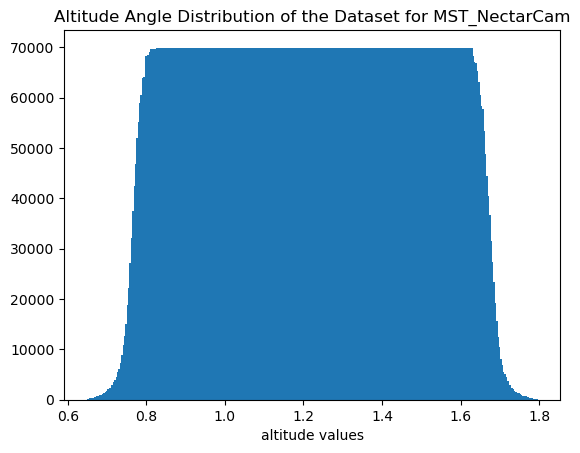

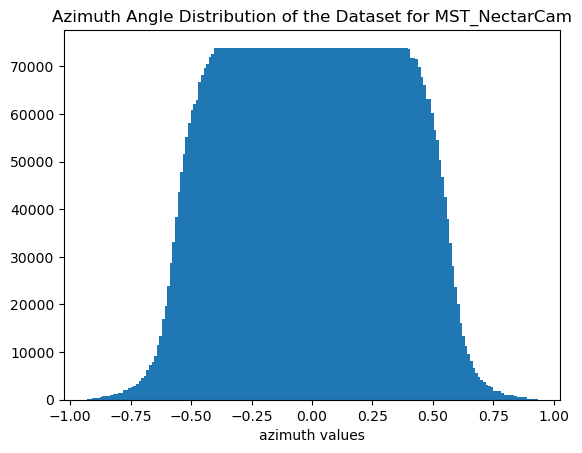

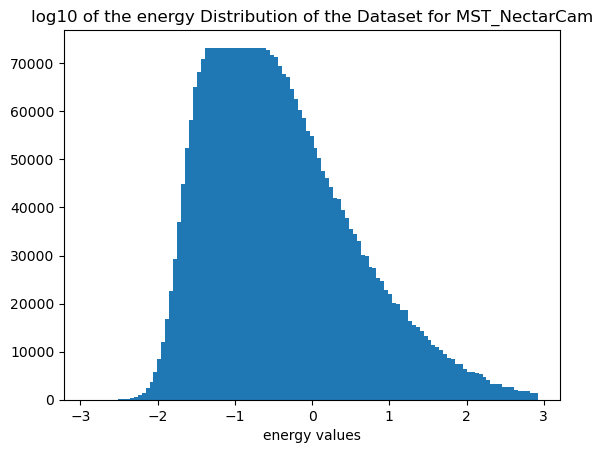

In [17]:
plt.bar(np.linspace(alt_min, alt_max, 100), alt_distribution_MST)
plt.xlabel("altitude values")
plt.title("Altitude Angle Distribution of the Dataset for MST_NectarCam")
plt.show()
plt.bar(np.linspace(az_min, az_max, 100), az_distribution_MST)
plt.xlabel("azimuth values")
plt.title("Azimuth Angle Distribution of the Dataset for MST_NectarCam")
plt.show()
plt.bar(np.linspace(log10_energy_min, log10_energy_max, 100), log10_energy_distribution_MST)
plt.xlabel("energy values")
plt.title("log10 of the energy Distribution of the Dataset for MST_NectarCam")
plt.show()